# 11 — Fine-tuned ChemBERTa: does a more advanced model do better?

Every model so far reads a molecule as a **Morgan fingerprint**: 2,048 on/off bits, each saying whether a small substructure appears. The best of them, the tuned SVR, gets within about 0.14 pKi of the measurement-noise floor (notebook 10).

This notebook tries the "everything included" option: **ChemBERTa**, a transformer language model that reads a molecule's SMILES text the way a chatbot reads a sentence. It was pretrained by DeepChem on 77 million molecules, and here every one of its layers is retrained (**fine-tuned**) to predict CB2 pKi. It is built in PyTorch, so you can watch it learn, epoch by epoch, in the notebook and in TensorBoard.

It then tries the opposite (section 6): the same pretrained ChemBERTa **frozen**, not retrained at all. It only turns each molecule into a list of numbers, and an SVR, tuned exactly like the fingerprint SVR, learns pKi from those. Fine-tuning lets a big model reshape itself around the training molecules, which can mean memorizing them; freezing it rules that out.

**The question:** does a much bigger, more modern model beat the SVR on the same molecules, and does it matter whether it is fine-tuned?

**Keeping the comparison fair:**
- The same random and scaffold splits, the same 5 cross-validation folds the SVR used, and the same validation molecules.
- Settings were fixed before running and are **not tuned** on validation scores.
- Validation molecules are only predicted, never trained on. Test molecules are dropped at the start and never touched.

**Running it:** install the extra packages once (see `requirements-deep-learning.txt`). With an NVIDIA GPU, training takes about 10 minutes; on a CPU only, it takes hours. To watch training live in TensorBoard, run this in an Ubuntu terminal and open http://localhost:6006:

```
.venv/bin/tensorboard --logdir provenance/models/fine_tuned_chemberta/tensorboard
```

Saved results go to `provenance/models/fine_tuned_chemberta/` and figures to `results/`.

In [1]:
from pathlib import Path
import sys
# Find the project folder whether the notebook runs from notebooks/ or the project root.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
import copy
import json
import shutil
import time
import warnings
# Hide a harmless notice about progress-bar widgets that VS Code doesn't need.
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from torch.utils.tensorboard import SummaryWriter
from transformers import AutoModel, AutoTokenizer
from provenance_support import current_preparation
import huggingface_hub

# Each model load prints a long report. It lists the pretraining word-guessing layer ("lm_head"),
# which is deliberately discarded, and an unused "pooler" layer; neither affects this model. Hide it.
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()
huggingface_hub.logging.set_verbosity_error()

# Every setting is fixed here, before any training, and none is changed after seeing scores.
MODEL_NAME = "DeepChem/ChemBERTa-77M-MLM"   # Pretrained on 77 million molecules from PubChem.
SETTINGS = {
    "encoder_learning_rate": 5e-5,   # Small steps for the pretrained layers, so they adjust without forgetting.
    "head_learning_rate": 1e-3,      # Bigger steps for the new output layer, which starts from scratch.
    "weight_decay": 0.01,            # Gently pulls weights toward zero to limit memorizing.
    "batch_size": 32,                # Molecules per training step.
    "dropout": 0.1,                  # Randomly hides 10% of the vector during training, another guard against memorizing.
    "max_epochs": 50,                # Hard upper limit on passes through the training molecules.
    "patience": 10,                  # Stop after 10 epochs with no improvement on the held-out fold.
    "seed": 42,                      # Same starting randomness for every fold model.
}
NOISE_FLOOR = 0.54   # Published SD of public ChEMBL Ki values, in pKi (Kramer et al. 2012); see notebook 10.
SPLITS = ["random", "scaffold"]
FOLDS = [1, 2, 3, 4, 5]

# Where results go. TensorBoard logs are large binary files, so git ignores them.
output_folder = project_root / "provenance/models/fine_tuned_chemberta"
board_folder = output_folder / "tensorboard"
output_folder.mkdir(parents=True, exist_ok=True)

# Use the GPU when PyTorch can see one; otherwise fall back to the (much slower) CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name = torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU only"
print(f"PyTorch {torch.__version__}, Transformers {transformers.__version__}")
print(f"Training device: {device_name}")
if device.type == "cpu":
    print("No GPU found: expect several hours instead of about 10 minutes.")

PyTorch 2.14.1+cu130, Transformers 5.18.0
Training device: NVIDIA GeForce RTX 4070 Ti SUPER


## 1. Load the same molecules, splits and folds as every other model

The pKi values come from the frozen preparation file (notebook 03). The split labels say which molecules are training, validation or test. The fold numbers are the exact 5 cross-validation folds the tuned SVR used (notebook 07), so each fine-tuned model holds out the same molecules the SVR's search did.

In [2]:
# The preparation manifest points to the frozen dataset every model notebook reads.
preparation_folder = project_root / current_preparation(project_root).parent
with np.load(preparation_folder / "fingerprints_and_targets.npz", allow_pickle=False) as saved:
    pki_values = saved["y"]
    smiles_keys = saved["rdkit_smiles"]
    fingerprints = saved["X"]   # Only used later, to compare chemical neighborhoods.
all_molecules = pd.DataFrame({"rdkit_smiles": smiles_keys, "pki": pki_values})

assignments = pd.read_csv(preparation_folder / "split_assignments.csv", keep_default_na=False)
cv_folds = pd.read_csv(project_root / "provenance/models/support_vector_regression/files/tuning/cv_folds.csv",
                       keep_default_na=False)

# One table per split. Test molecules are dropped here, so no later step can use them by mistake.
molecules = {}
for split in SPLITS:
    subset = assignments[assignments["split_strategy"] == split].set_index("rdkit_smiles")["subset"]
    fold = cv_folds[cv_folds["split_strategy"] == split].set_index("rdkit_smiles")["cv_validation_fold"]
    table = all_molecules.assign(subset=all_molecules["rdkit_smiles"].map(subset))
    table = table[table["subset"] != "test"].copy()
    # Fold 0 marks validation molecules: they belong to no training fold.
    table["fold"] = table["rdkit_smiles"].map(fold).fillna(0).astype(int)

    # Safeguards: every training molecule has a fold 1-5, and no validation molecule has one.
    assert table["subset"].isin(["train", "validation"]).all()
    assert table.loc[table["subset"] == "train", "fold"].isin(FOLDS).all()
    assert (table.loc[table["subset"] == "validation", "fold"] == 0).all()
    molecules[split] = table.reset_index(drop=True)

print(f"{'Split':<10} | {'Training':>9} | {'Validation':>10} | {'Molecules per fold':<30}")
for split in SPLITS:
    table = molecules[split]
    fold_sizes = table.loc[table["subset"] == "train", "fold"].value_counts().sort_index().tolist()
    print(f"{split:<10} | {(table['subset'] == 'train').sum():>9,} | {(table['subset'] == 'validation').sum():>10,} | "
          f"{', '.join(str(n) for n in fold_sizes):<30}")

Split      |  Training | Validation | Molecules per fold            
random     |     2,860 |        358 | 572, 572, 572, 572, 572       
scaffold   |     2,778 |        461 | 556, 556, 556, 555, 555       


## 2. The model: a pretrained reader plus one new output layer

1. **Tokenizer.** Splits the SMILES text into pieces (atoms, bonds, ring numbers) and turns each piece into a number.
2. **Encoder (pretrained).** The transformer. It turns each piece into a 384-number vector that depends on the whole molecule around it. These layers start from what ChemBERTa learned on 77 million molecules.
3. **Averaging.** The piece vectors are averaged into one vector per molecule.
4. **Head (new).** One linear layer turns that vector into a pKi prediction. It starts from random numbers.

Fine-tuning trains the encoder and head together, so the encoder can reshape its picture of molecules around CB2 affinity.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# What the model actually reads: the SMILES text, cut into pieces.
example = molecules["random"]["rdkit_smiles"].iloc[0]
print("SMILES:", example)
print("Pieces:", tokenizer.tokenize(example))


class ChembertaRegressor(torch.nn.Module):
    # Pretrained encoder -> average of the piece vectors -> dropout -> one linear output (pKi).
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = torch.nn.Dropout(SETTINGS["dropout"])
        self.head = torch.nn.Linear(self.encoder.config.hidden_size, 1)

    def molecule_vectors(self, batch):
        # One vector per piece; the attention mask marks real pieces versus padding.
        piece_vectors = self.encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1).float()
        # Average only over real pieces, so padding added to short SMILES doesn't count.
        return (piece_vectors * mask).sum(dim=1) / mask.sum(dim=1)

    def forward(self, batch):
        return self.head(self.dropout(self.molecule_vectors(batch))).squeeze(-1)


preview = ChembertaRegressor()
parameter_count = sum(p.numel() for p in preview.parameters())
print(f"\nTrainable numbers (parameters): {parameter_count:,}")
print("For comparison, the MLP in notebooks 08-09 had about 66,000.")
del preview

SMILES: Brc1ccc2c(c1)c(OCc1ccc3ccccc3c1)nn2CCN1CCCCC1
Pieces: ['B', 'c', '1', 'c', 'c', 'c', '2', 'c', '(', 'c', '1', ')', 'c', '(', 'O', 'C', 'c', '1', 'c', 'c', 'c', '3', 'c', 'c', 'c', 'c', 'c', '3', 'c', '1', ')', 'n', 'n', '2', 'C', 'C', 'N', '1', 'C', 'C', 'C', 'C', 'C', '1']



Trainable numbers (parameters): 3,427,825
For comparison, the MLP in notebooks 08-09 had about 66,000.


## 3. The training rule (fixed before running)

For each split, **five separate models** are trained, one per cross-validation fold:

- Each trains on **four** of the five training folds.
- The **fifth** (still training data) is the model's practice exam. After every epoch (one pass through the training molecules), its error there is measured.
- When that error hasn't improved for 10 epochs, training stops, and the model rewinds to its best epoch. This is **early stopping**: it catches the point where the model starts memorizing the training molecules instead of learning rules that carry over.
- The five models' predictions on the validation molecules are then **averaged**. That average is the final prediction, and it is scored only once, in section 5.

pKi values are rescaled to mean 0 and SD 1 for training (using training molecules only), which helps the network learn smoothly; predictions are converted back to pKi.

The two helpers below run the model in batches. `predict` gives pKi predictions; `molecule_vectors` gives the 384-number vector for each molecule, used for the chemical-space map in section 6.

In [4]:
def batches(smiles, size=128):
    # Tokenize a list of SMILES in chunks; padding makes every SMILES in a chunk the same length.
    for start in range(0, len(smiles), size):
        yield tokenizer(list(smiles[start:start + size]), padding=True, return_tensors="pt").to(device)


def predict(model, smiles):
    # eval() switches dropout off, and no_grad() skips the bookkeeping needed only for training.
    model.eval()
    with torch.no_grad():
        return torch.cat([model(batch) for batch in batches(smiles)]).cpu().numpy()


def molecule_vectors(model, smiles):
    model.eval()
    with torch.no_grad():
        return torch.cat([model.molecule_vectors(batch) for batch in batches(smiles)]).cpu().numpy()


def rmse(predicted, observed):
    return float(np.sqrt(np.mean((np.asarray(predicted) - np.asarray(observed)) ** 2)))

## 4. Train the 10 models and watch them learn

The figure below redraws after every epoch. Faint lines are the five individual fold models; bold lines are their average.

- **Blue: training error.** How wrong the models are on the molecules they are learning from.
- **Orange: held-out fold error.** How wrong they are on training molecules they are *not* learning from. This is the line that matters.
- **Dots:** each model's best epoch, the one it rewinds to.
- **Shaded band: the memorizing gap.** Blue keeps falling, even below the noise floor, which no real skill can do. Orange flattens early. The widening band is the models memorizing their training molecules instead of learning rules that carry over.

The bold lines stop once fewer than three fold models are still training, because an "average" of one or two models would be misleading.

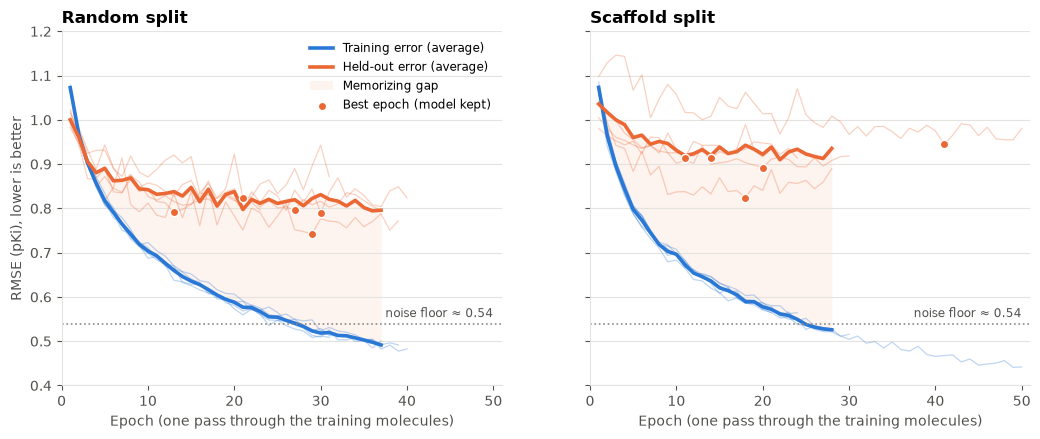

Split      | Fold | Best epoch | Epochs run | Held-out RMSE | Seconds
random     |    1 |         29 |         39 |         0.742 |      44
random     |    2 |         21 |         31 |         0.823 |      33
random     |    3 |         30 |         40 |         0.790 |      43
random     |    4 |         27 |         37 |         0.795 |      40
random     |    5 |         13 |         23 |         0.791 |      25
scaffold   |    1 |         11 |         21 |         0.914 |      23
scaffold   |    2 |         41 |         50 |         0.945 |      53
scaffold   |    3 |         14 |         24 |         0.913 |      26
scaffold   |    4 |         20 |         30 |         0.892 |      32
scaffold   |    5 |         18 |         28 |         0.824 |      30

All 10 models trained in 5.8 minutes.


In [5]:
# Clear logs from an earlier run, so TensorBoard shows only this one.
shutil.rmtree(board_folder, ignore_errors=True)

INK_SECONDARY, GRID = "#52514e", "#e4e3df"
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.edgecolor": GRID,
                     "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
                     "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})


TRAIN_COLOR, HELD_OUT_COLOR = "#2a78d6", "#eb6834"   # One color per kind of error, not per fold.


def draw_curves(axes, history, best_epochs):
    # Draw every finished or running fold model's curves; reused for the live view and the saved figure.
    # Faint lines are the individual fold models; bold lines are their average.
    for ax, split in zip(axes, SPLITS):
        ax.clear()
        rows = history[history["split_strategy"] == split]
        for fold in FOLDS:
            fold_rows_ = rows[rows["fold"] == fold]
            ax.plot(fold_rows_["epoch"], fold_rows_["training_rmse"], color=TRAIN_COLOR, linewidth=0.9, alpha=0.3)
            ax.plot(fold_rows_["epoch"], fold_rows_["held_out_rmse"], color=HELD_OUT_COLOR, linewidth=0.9, alpha=0.3)
            if (split, fold) in best_epochs:
                best = fold_rows_[fold_rows_["epoch"] == best_epochs[split, fold]].iloc[0]
                ax.scatter(best["epoch"], best["held_out_rmse"], color=HELD_OUT_COLOR, s=36, zorder=4,
                           edgecolor="white", linewidth=1)
        if not rows.empty:
            # Average over the fold models still training at each epoch. Once fewer than 3 remain,
            # the "average" would just be one or two models, so the bold lines stop there.
            by_epoch = rows.groupby("epoch").agg(training=("training_rmse", "mean"), held_out=("held_out_rmse", "mean"),
                                                 models=("fold", "size"))
            by_epoch = by_epoch[by_epoch["models"] >= min(3, rows["fold"].nunique())]
            ax.plot(by_epoch.index, by_epoch["training"], color=TRAIN_COLOR, linewidth=2.6, label="Training error (average)")
            ax.plot(by_epoch.index, by_epoch["held_out"], color=HELD_OUT_COLOR, linewidth=2.6, label="Held-out error (average)")
            # The shaded band is the memorizing gap: how much better the model does on molecules it learns from.
            ax.fill_between(by_epoch.index, by_epoch["training"], by_epoch["held_out"], color=HELD_OUT_COLOR,
                            alpha=0.08, linewidth=0, label="Memorizing gap")
        ax.axhline(NOISE_FLOOR, color="#8a8984", linestyle=":", linewidth=1.2)
        ax.text(SETTINGS["max_epochs"], NOISE_FLOOR + 0.008, f"noise floor ≈ {NOISE_FLOOR}", ha="right", va="bottom",
                fontsize=8.5, color=INK_SECONDARY)
        ax.set_title(f"{split.title()} split", loc="left")
        ax.set_xlabel("Epoch (one pass through the training molecules)")
        ax.set_xlim(0, SETTINGS["max_epochs"] + 1)
        ax.set_ylim(0.4, 1.2)   # Zoomed in: every curve lives between these values.
        ax.grid(axis="y", color=GRID, linewidth=0.8)
    axes[0].set_ylabel("RMSE (pKi), lower is better")
    axes[0].scatter([], [], color=HELD_OUT_COLOR, s=36, edgecolor="white", label="Best epoch (model kept)")
    axes[0].legend(loc="upper right", fontsize=8.5)


live_figure, live_axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
live_view = display(live_figure, display_id=True)   # A display we can update in place.
plt.close(live_figure)                              # Stop Jupyter from also drawing a second copy.

history_rows, prediction_rows, best_epochs, fold_rows = [], [], {}, []
saved_vectors = None   # The random-split fold-1 model's molecule vectors, for section 6.
started_all = time.time()

for split in SPLITS:
    table = molecules[split]
    for fold in FOLDS:
        started = time.time()
        # Four training folds to learn from, one held-out training fold to decide when to stop.
        train = table[(table["subset"] == "train") & (table["fold"] != fold)]
        held_out = table[table["fold"] == fold]
        validation = table[table["subset"] == "validation"]   # Only predicted, after training ends.

        # Rescale pKi with training-fold statistics only, so nothing leaks from held-out molecules.
        pki_mean, pki_sd = train["pki"].mean(), train["pki"].std()
        train_smiles = train["rdkit_smiles"].to_numpy()
        train_targets = ((train["pki"] - pki_mean) / pki_sd).to_numpy(np.float32)

        # A fresh copy of the pretrained model for every fold, with the same starting randomness.
        torch.manual_seed(SETTINGS["seed"])
        model = ChembertaRegressor().to(device)
        optimizer = torch.optim.AdamW([
            {"params": model.encoder.parameters(), "lr": SETTINGS["encoder_learning_rate"]},
            {"params": model.head.parameters(), "lr": SETTINGS["head_learning_rate"]},
        ], weight_decay=SETTINGS["weight_decay"])
        shuffler = np.random.default_rng(SETTINGS["seed"])
        writer = SummaryWriter(board_folder / f"{split}_fold{fold}")

        best_rmse, best_state, best_epoch, epochs_without_improvement = np.inf, None, 0, 0
        for epoch in range(1, SETTINGS["max_epochs"] + 1):
            # One epoch: every training molecule once, in a new random order, in batches of 32.
            model.train()
            order = shuffler.permutation(len(train_smiles))
            batch_losses = []
            for start in range(0, len(order), SETTINGS["batch_size"]):
                rows = order[start:start + SETTINGS["batch_size"]]
                batch = tokenizer(list(train_smiles[rows]), padding=True, return_tensors="pt").to(device)
                loss = torch.nn.functional.mse_loss(model(batch), torch.from_numpy(train_targets[rows]).to(device))
                optimizer.zero_grad()   # Forget the previous step's gradients.
                loss.backward()         # Work out how each weight should change to reduce the error.
                optimizer.step()        # Change the weights a little in that direction.
                batch_losses.append(loss.item())

            # Training error in pKi units (converted back from the rescaled loss) and held-out fold error.
            training_rmse = float(np.sqrt(np.mean(batch_losses))) * pki_sd
            held_out_rmse = rmse(predict(model, held_out["rdkit_smiles"].to_numpy()) * pki_sd + pki_mean, held_out["pki"])
            history_rows.append({"split_strategy": split, "fold": fold, "epoch": epoch,
                                 "training_rmse": training_rmse, "held_out_rmse": held_out_rmse})
            writer.add_scalar("rmse_pki/training", training_rmse, epoch)
            writer.add_scalar("rmse_pki/held_out_fold", held_out_rmse, epoch)

            # Early stopping: keep a copy of the best weights; stop after 10 epochs without improvement.
            if held_out_rmse < best_rmse - 1e-4:
                best_rmse, best_state, best_epoch = held_out_rmse, copy.deepcopy(model.state_dict()), epoch
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            draw_curves(live_axes, pd.DataFrame(history_rows), best_epochs)
            live_view.update(live_figure)
            if epochs_without_improvement >= SETTINGS["patience"]:
                break

        # Rewind to the best epoch, then predict the held-out fold and the validation molecules.
        model.load_state_dict(best_state)
        best_epochs[split, fold] = best_epoch
        for role, rows in [("held_out_training_fold", held_out), ("validation", validation)]:
            predicted = predict(model, rows["rdkit_smiles"].to_numpy()) * pki_sd + pki_mean
            prediction_rows.append(pd.DataFrame({"split_strategy": split, "fold_model": fold, "role": role,
                                                 "rdkit_smiles": rows["rdkit_smiles"].to_numpy(),
                                                 "observed_pki": rows["pki"].to_numpy(), "predicted_pki": predicted}))
        if split == "random" and fold == 1:
            # Keep this one model's view of chemical space (training + validation molecules) for section 6.
            saved_vectors = molecule_vectors(model, table["rdkit_smiles"].to_numpy())
            writer.add_embedding(torch.from_numpy(saved_vectors), metadata=[f"{p:.2f}" for p in table["pki"]],
                                 tag="fine_tuned_molecules")
        writer.close()
        fold_rows.append({"split_strategy": split, "fold": fold, "best_epoch": best_epoch, "epochs_run": epoch,
                          "best_held_out_rmse": best_rmse, "seconds": time.time() - started})
        del model, optimizer, best_state
        if device.type == "cuda":
            torch.cuda.empty_cache()   # Hand GPU memory back before the next fold model.

draw_curves(live_axes, pd.DataFrame(history_rows), best_epochs)
live_view.update(live_figure)
history = pd.DataFrame(history_rows)
predictions = pd.concat(prediction_rows, ignore_index=True)
fold_summary = pd.DataFrame(fold_rows)

print(f"{'Split':<10} | {'Fold':>4} | {'Best epoch':>10} | {'Epochs run':>10} | {'Held-out RMSE':>13} | {'Seconds':>7}")
for row in fold_summary.itertuples():
    print(f"{row.split_strategy:<10} | {row.fold:>4} | {row.best_epoch:>10} | {row.epochs_run:>10} | "
          f"{row.best_held_out_rmse:>13.3f} | {row.seconds:>7.0f}")
print(f"\nAll 10 models trained in {(time.time() - started_all) / 60:.1f} minutes.")

### The finished training curves

The same picture, saved to `results/chemberta_training.png`. The numbers below it put the memorizing gap in figures: at each model's best epoch, how far its training error sits below its held-out error.

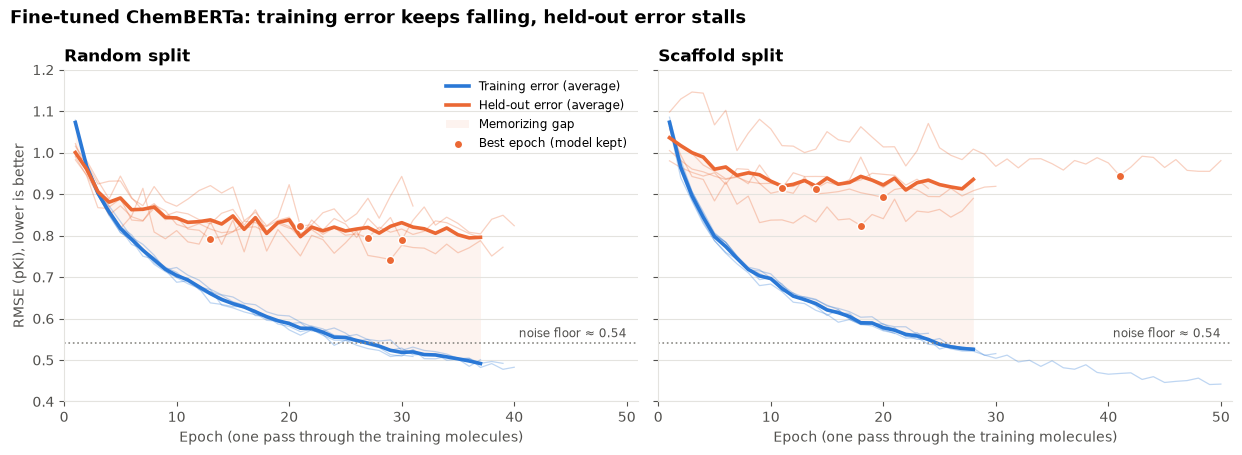

Split      | Fold | Train RMSE @ best | Held-out @ best | Train RMSE @ last
random     |    1 |             0.548 |           0.742 |             0.492
random     |    2 |             0.560 |           0.823 |             0.509
random     |    3 |             0.529 |           0.790 |             0.483
random     |    4 |             0.537 |           0.795 |             0.501
random     |    5 |             0.665 |           0.791 |             0.568
scaffold   |    1 |             0.667 |           0.914 |             0.564
scaffold   |    2 |             0.468 |           0.945 |             0.442
scaffold   |    3 |             0.647 |           0.913 |             0.564
scaffold   |    4 |             0.572 |           0.892 |             0.516
scaffold   |    5 |             0.585 |           0.824 |             0.528


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
draw_curves(axes, history, best_epochs)
fig.suptitle("Fine-tuned ChemBERTa: training error keeps falling, held-out error stalls", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(project_root / "results/chemberta_training.png", dpi=200, bbox_inches="tight", metadata={"Software": None})
plt.show()

# Memorizing gap at the best epoch, and at the last epoch run.
print(f"{'Split':<10} | {'Fold':>4} | {'Train RMSE @ best':>17} | {'Held-out @ best':>15} | {'Train RMSE @ last':>17}")
for (split, fold), best_epoch in best_epochs.items():
    rows = history[(history["split_strategy"] == split) & (history["fold"] == fold)]
    at_best = rows[rows["epoch"] == best_epoch].iloc[0]
    print(f"{split:<10} | {fold:>4} | {at_best['training_rmse']:>17.3f} | {at_best['held_out_rmse']:>15.3f} | "
          f"{rows['training_rmse'].iloc[-1]:>17.3f}")

## 5. Score on the validation molecules, against the tuned SVR

The five fold models' predictions are averaged for each validation molecule, then scored exactly like every other model. The tuned SVR and dummy scores are read from their saved prediction files.

**Is a difference real?** With a few hundred molecules, one model can win by luck. So the validation molecules are resampled 2,000 times (the same draws for both models), and the RMSE difference is recomputed each time. If the middle 95% of those differences doesn't include zero, the difference is real.

**Gap closed** is the scale from notebook 10: 0% is no better than the dummy, 100% reaches the noise floor.

In [7]:
def saved_validation(path, split):
    # One model's saved validation predictions for one split, indexed by molecule.
    frame = pd.read_csv(project_root / path)
    frame = frame[(frame["split_strategy"] == split) & (frame["subset"] == "validation")]
    return frame.set_index("rdkit_smiles")


rng = np.random.default_rng(42)
results, differences = [], {}
for split in SPLITS:
    # Average the five fold models' predictions for each validation molecule.
    rows = predictions[(predictions["split_strategy"] == split) & (predictions["role"] == "validation")]
    assert (rows.groupby("rdkit_smiles").size() == len(FOLDS)).all()   # Every molecule predicted by all 5 models.
    chemberta = rows.groupby("rdkit_smiles")["predicted_pki"].mean()
    observed = rows.groupby("rdkit_smiles")["observed_pki"].first()

    svr = saved_validation("provenance/models/support_vector_regression/files/tuning/predictions.csv", split)
    dummy = saved_validation("provenance/models/dummy_baselines/files/tuning/predictions.csv", split)
    # Safeguard: exactly the same molecules with the same measured pKi as the saved models.
    assert set(svr.index) == set(observed.index) == set(dummy.index)
    keys = observed.index
    assert np.allclose(svr.loc[keys, "observed_pki"], observed.loc[keys])

    draws = rng.integers(0, len(keys), (2000, len(keys)))   # Same resampled molecule sets for every model.
    resampled = {}
    for name, predicted in [("Dummy (no skill)", dummy.loc[keys, "predicted_pki"]),
                            ("Tuned SVR", svr.loc[keys, "predicted_pki"]),
                            ("Fine-tuned ChemBERTa", chemberta.loc[keys])]:
        errors = predicted.to_numpy() - observed.loc[keys].to_numpy()
        resampled[name] = np.sqrt((errors ** 2)[draws].mean(axis=1))
        results.append({"split_strategy": split, "model": name, "rmse": rmse(predicted, observed.loc[keys]),
                        "mae": float(np.mean(np.abs(errors))),
                        "r2": 1 - np.sum(errors ** 2) / np.sum((observed - observed.mean()) ** 2),
                        "rmse_low": np.percentile(resampled[name], 2.5),
                        "rmse_high": np.percentile(resampled[name], 97.5)})
    differences[split] = resampled["Fine-tuned ChemBERTa"] - resampled["Tuned SVR"]

results = pd.DataFrame(results)
no_skill = results[results["model"] == "Dummy (no skill)"].set_index("split_strategy")["rmse"]
results["gap_closed"] = (results["split_strategy"].map(no_skill) - results["rmse"]) / (results["split_strategy"].map(no_skill) - NOISE_FLOOR)

print(f"{'Split':<9} | {'Model':<22} | {'RMSE':>6} | {'95% interval':>13} | {'MAE':>6} | {'R²':>6} | {'Gap closed':>10}")
for row in results.itertuples():
    print(f"{row.split_strategy:<9} | {row.model:<22} | {row.rmse:>6.3f} | {row.rmse_low:.3f} - {row.rmse_high:.3f} | "
          f"{row.mae:>6.3f} | {row.r2:>6.3f} | {row.gap_closed:>10.0%}")
print()
for split in SPLITS:
    low, high = np.percentile(differences[split], [2.5, 97.5])
    verdict = "ChemBERTa is really better" if high < 0 else "ChemBERTa is really worse" if low > 0 else "not distinguishable"
    print(f"{split:<9}: ChemBERTa minus SVR RMSE = {differences[split].mean():+.3f} pKi "
          f"(95% interval {low:+.3f} to {high:+.3f}) -> {verdict}")

Split     | Model                  |   RMSE |  95% interval |    MAE |     R² | Gap closed
random    | Dummy (no skill)       |  1.189 | 1.110 - 1.263 |  0.972 | -0.001 |         0%
random    | Tuned SVR              |  0.685 | 0.631 - 0.740 |  0.523 |  0.668 |        78%
random    | Fine-tuned ChemBERTa   |  0.770 | 0.716 - 0.825 |  0.608 |  0.580 |        65%
scaffold  | Dummy (no skill)       |  1.147 | 1.088 - 1.210 |  0.956 | -0.004 |         0%
scaffold  | Tuned SVR              |  0.764 | 0.717 - 0.814 |  0.601 |  0.555 |        63%
scaffold  | Fine-tuned ChemBERTa   |  0.922 | 0.862 - 0.981 |  0.728 |  0.352 |        37%

random   : ChemBERTa minus SVR RMSE = +0.085 pKi (95% interval +0.038 to +0.131) -> ChemBERTa is really worse
scaffold : ChemBERTa minus SVR RMSE = +0.158 pKi (95% interval +0.108 to +0.206) -> ChemBERTa is really worse


## 6. The same ChemBERTa, without fine-tuning

Fine-tuning retrains all 3.4 million of ChemBERTa's numbers on about 2,300 molecules per fold model. Section 4 showed what that invites: training error falling far below the noise floor, which no real skill can reach, while held-out error stalls. The model is partly memorizing its training molecules.

So here is the opposite approach. ChemBERTa is **frozen**: never retrained, used only as a reader that turns each molecule into its 384-number vector, exactly as it came from pretraining on 77 million molecules. An **SVR** then learns pKi from those vectors.

**Keeping it fair**, the SVR is set up exactly like the tuned fingerprint SVR of notebook 07, fixed before running:
- the same settings grid (read from notebook 07's saved configuration, not retyped), searched with the same five cross-validation folds and the same rule (lowest mean fold error);
- the same training molecules, then a single prediction of the same validation molecules;
- scored on the same 2,000 resampled molecule sets as section 5, so every comparison is paired.

One difference is necessary: fingerprint bits are all 0 or 1, but ChemBERTa's vector entries are on different scales, so each is rescaled to mean 0 and SD 1 before the SVR sees it. The rescaling is learned from training molecules only, inside each fold.

In [8]:
# The pretrained encoder alone, with the same averaging over SMILES pieces as the fine-tuned model,
# but never trained on pKi. It only reads molecules here.
frozen_encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()


def pretrained_vectors(smiles):
    # One 384-number vector per molecule: the average of its piece vectors, padding excluded.
    chunks = []
    with torch.no_grad():
        for batch in batches(smiles):
            piece_vectors, mask = frozen_encoder(**batch).last_hidden_state, batch["attention_mask"].unsqueeze(-1).float()
            chunks.append(((piece_vectors * mask).sum(dim=1) / mask.sum(dim=1)).cpu().numpy())
    return np.vstack(chunks)


# The tuned fingerprint SVR's own search settings (notebook 07), read from its saved configuration.
svr_configuration = json.loads((project_root / "provenance/models/support_vector_regression/files/tuning/manifest.json")
                               .read_text(encoding="utf-8"))["configuration"]
FROZEN_GRID = svr_configuration["parameter_grid"]
print(f"Settings searched (from notebook 07): {FROZEN_GRID}; scoring: {svr_configuration['scoring']}\n")

frozen_rows, frozen_selection = [], {}
for split in SPLITS:
    table = molecules[split]
    vectors = pretrained_vectors(table["rdkit_smiles"].to_numpy())
    is_train = (table["subset"] == "train").to_numpy()
    is_validation = (table["subset"] == "validation").to_numpy()

    # PredefinedSplit reuses the exact fold numbers saved by notebook 07, so each candidate setting is
    # scored on the same five held-out folds as the fingerprint SVR's search.
    search = GridSearchCV(make_pipeline(StandardScaler(), SVR(kernel="rbf")),
                          {f"svr__{name}": values for name, values in FROZEN_GRID.items()},
                          scoring=svr_configuration["scoring"],
                          cv=PredefinedSplit(table.loc[is_train, "fold"].to_numpy()), refit=True, n_jobs=-1)
    search.fit(vectors[is_train], table.loc[is_train, "pki"].to_numpy())

    # One prediction of the validation molecules, by the setting chosen on the training folds.
    frozen_rows.append(pd.DataFrame({"split_strategy": split, "subset": "validation",
                                     "rdkit_smiles": table.loc[is_validation, "rdkit_smiles"].to_numpy(),
                                     "observed_pki": table.loc[is_validation, "pki"].to_numpy(),
                                     "predicted_pki": search.predict(vectors[is_validation])}))
    frozen_selection[split] = {"best_parameters": {k.removeprefix("svr__"): v for k, v in search.best_params_.items()},
                               "best_mean_cv_mae_pki": float(-search.best_score_),
                               "training_molecules": int(is_train.sum())}
    print(f"{split:<9}: chose {frozen_selection[split]['best_parameters']} "
          f"(mean fold MAE {frozen_selection[split]['best_mean_cv_mae_pki']:.3f} pKi)")
del frozen_encoder
if device.type == "cuda":
    torch.cuda.empty_cache()
frozen_predictions = pd.concat(frozen_rows, ignore_index=True)

# Score exactly as in section 5. The random generator is restarted with the same seed and used in the
# same order, so these are the very same 2,000 resampled molecule sets: every comparison is paired.
rng = np.random.default_rng(42)
frozen_results, frozen_differences = [], {}
for split in SPLITS:
    rows = predictions[(predictions["split_strategy"] == split) & (predictions["role"] == "validation")]
    observed = rows.groupby("rdkit_smiles")["observed_pki"].first()
    fine_tuned = rows.groupby("rdkit_smiles")["predicted_pki"].mean()
    svr = saved_validation("provenance/models/support_vector_regression/files/tuning/predictions.csv", split)["predicted_pki"]
    frozen = frozen_predictions[frozen_predictions["split_strategy"] == split].set_index("rdkit_smiles")["predicted_pki"]
    keys = observed.index
    assert set(frozen.index) == set(keys)   # Safeguard: exactly the validation molecules of section 5.
    draws = rng.integers(0, len(keys), (2000, len(keys)))

    def resampled_rmse(predicted):
        return np.sqrt(((predicted.loc[keys].to_numpy() - observed.loc[keys].to_numpy()) ** 2)[draws].mean(axis=1))

    errors = frozen.loc[keys].to_numpy() - observed.loc[keys].to_numpy()
    samples = resampled_rmse(frozen)
    frozen_results.append({"split_strategy": split, "model": "Frozen ChemBERTa + SVR", "rmse": rmse(frozen.loc[keys], observed.loc[keys]),
                           "mae": float(np.mean(np.abs(errors))),
                           "r2": 1 - np.sum(errors ** 2) / np.sum((observed - observed.mean()) ** 2),
                           "rmse_low": np.percentile(samples, 2.5), "rmse_high": np.percentile(samples, 97.5),
                           "gap_closed": (no_skill[split] - rmse(frozen.loc[keys], observed.loc[keys])) / (no_skill[split] - NOISE_FLOOR)})
    frozen_differences[split] = {"the tuned SVR": samples - resampled_rmse(svr),
                                 "fine-tuned ChemBERTa": samples - resampled_rmse(fine_tuned)}

results = pd.concat([results, pd.DataFrame(frozen_results)], ignore_index=True)
print(f"\n{'Split':<9} | {'Model':<22} | {'RMSE':>6} | {'95% interval':>13} | {'Gap closed':>10}")
for row in results[~results["model"].str.startswith("Dummy")].sort_values(["split_strategy", "rmse"]).itertuples():
    print(f"{row.split_strategy:<9} | {row.model:<22} | {row.rmse:>6.3f} | {row.rmse_low:.3f} - {row.rmse_high:.3f} | {row.gap_closed:>10.0%}")
print()
for split in SPLITS:
    for other, difference in frozen_differences[split].items():
        low, high = np.percentile(difference, [2.5, 97.5])
        verdict = "frozen is really better" if high < 0 else "frozen is really worse" if low > 0 else "not distinguishable"
        print(f"{split:<9}: frozen minus {other:<20} = {difference.mean():+.3f} pKi (95% interval {low:+.3f} to {high:+.3f}) -> {verdict}")

Settings searched (from notebook 07): {'C': [1.0, 10.0], 'epsilon': [0.1, 0.3], 'gamma': ['scale', 'auto']}; scoring: neg_mean_absolute_error



random   : chose {'C': 10.0, 'epsilon': 0.1, 'gamma': 'auto'} (mean fold MAE 0.552 pKi)


scaffold : chose {'C': 10.0, 'epsilon': 0.3, 'gamma': 'scale'} (mean fold MAE 0.665 pKi)

Split     | Model                  |   RMSE |  95% interval | Gap closed
random    | Tuned SVR              |  0.685 | 0.631 - 0.740 |        78%
random    | Frozen ChemBERTa + SVR |  0.716 | 0.660 - 0.772 |        73%
random    | Fine-tuned ChemBERTa   |  0.770 | 0.716 - 0.825 |        65%
scaffold  | Tuned SVR              |  0.764 | 0.717 - 0.814 |        63%
scaffold  | Frozen ChemBERTa + SVR |  0.805 | 0.752 - 0.857 |        56%
scaffold  | Fine-tuned ChemBERTa   |  0.922 | 0.862 - 0.981 |        37%

random   : frozen minus the tuned SVR        = +0.031 pKi (95% interval -0.009 to +0.074) -> not distinguishable
random   : frozen minus fine-tuned ChemBERTa = -0.054 pKi (95% interval -0.098 to -0.009) -> frozen is really better
scaffold : frozen minus the tuned SVR        = +0.040 pKi (95% interval -0.008 to +0.085) -> not distinguishable
scaffold : frozen minus fine-tuned ChemBERTa = -0.117 p

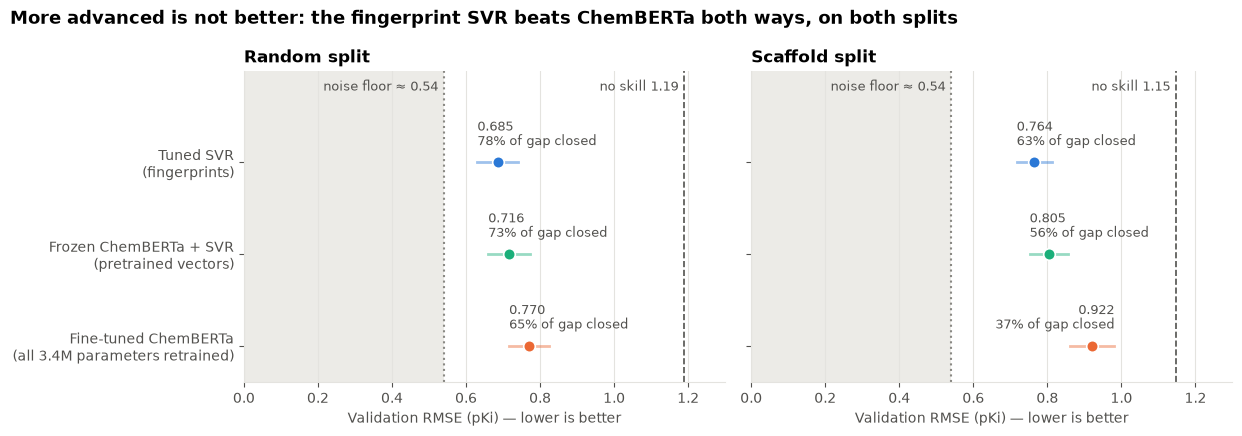

In [9]:
# Dot plot: each model's RMSE with its 95% interval, between the noise floor and the dummy.
BLUE, ORANGE, NEUTRAL, SHADE = "#2a78d6", "#eb6834", "#8a8984", "#ecebe7"
AQUA = "#1baf7a"   # Third categorical colour of the project's palette, for the frozen model.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharex=True, sharey=True)
for ax, split in zip(axes, SPLITS):
    ax.axvspan(0, NOISE_FLOOR, color=SHADE, linewidth=0, zorder=0)
    ax.axvline(NOISE_FLOOR, color=NEUTRAL, linestyle=":", linewidth=1.5)
    ax.axvline(no_skill[split], color=INK_SECONDARY, linestyle="--", linewidth=1.2)
    ax.text(NOISE_FLOOR - 0.015, 2.75, f"noise floor ≈ {NOISE_FLOOR:.2f}", ha="right", va="bottom", fontsize=9, color=INK_SECONDARY)
    ax.text(no_skill[split] - 0.015, 2.75, f"no skill {no_skill[split]:.2f}", ha="right", va="bottom", fontsize=9, color=INK_SECONDARY)
    for position, (name, color) in enumerate([("Fine-tuned ChemBERTa", ORANGE), ("Frozen ChemBERTa + SVR", AQUA),
                                              ("Tuned SVR", BLUE)]):
        row = results[(results["split_strategy"] == split) & (results["model"] == name)].iloc[0]
        ax.plot([row.rmse_low, row.rmse_high], [position, position], color=color, linewidth=2, alpha=0.45)
        ax.scatter(row.rmse, position, s=70, color=color, edgecolor="white", linewidth=1.2, zorder=3)
        # A short two-line label above the interval. It grows away from whichever line (floor or dummy)
        # is nearer, so it never crosses either one.
        nearer_dummy = row.rmse > (NOISE_FLOOR + no_skill[split]) / 2
        ax.text(row.rmse_high if nearer_dummy else row.rmse_low, position + 0.15,
                f"{row.rmse:.3f}\n{row.gap_closed:.0%} of gap closed",
                ha="right" if nearer_dummy else "left", va="bottom", fontsize=9, color=INK_SECONDARY, linespacing=1.2)
    ax.set_title(f"{split.title()} split", loc="left")
    ax.set_xlabel("Validation RMSE (pKi) — lower is better")
    ax.grid(axis="x", color=GRID, linewidth=0.8)
axes[0].set_yticks([0, 1, 2], ["Fine-tuned ChemBERTa\n(all 3.4M parameters retrained)",
                               "Frozen ChemBERTa + SVR\n(pretrained vectors)", "Tuned SVR\n(fingerprints)"])
axes[0].set_ylim(-0.4, 3.0)
axes[0].set_xlim(0, round(float(no_skill.max()) + 0.15, 1))
svr_rmse = results.query("model == 'Tuned SVR'")["rmse"].to_numpy()
fig.suptitle("More advanced is not better: the fingerprint SVR beats ChemBERTa both ways, on both splits"
             if all((results.query(f"model == '{name}'")["rmse"].to_numpy() > svr_rmse).all()
                    for name in ["Fine-tuned ChemBERTa", "Frozen ChemBERTa + SVR"])
             else "ChemBERTa, fine-tuned and frozen, versus the tuned SVR", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(project_root / "results/chemberta_vs_svr.png", dpi=200, bbox_inches="tight", metadata={"Software": None})
plt.show()

## 7. Chemical space: what did fine-tuning change?

ChemBERTa turns each molecule into a 384-number vector. Molecules with similar vectors are "neighbors" in the model's view. The maps below squash those vectors to 2D with **t-SNE**, which keeps neighbors close, and color each molecule by its pKi (darker = stronger binder). They use the random split's fold-1 model; test molecules are not shown.

- **Before:** the pretrained model, which never saw a pKi value.
- **After:** the same molecules after fine-tuning.

A t-SNE map is only a picture, so a number backs it up: for each validation molecule, find its 10 nearest training molecules and measure how far their average pKi is from its own pKi. Lower means neighbors share affinity, which is exactly what a model needs. The fingerprints the SVR uses are measured the same way, for reference.

Average pKi gap between a validation molecule and its 10 nearest training molecules (lower is better):
  No information (training average)     0.972 pKi
  ChemBERTa before fine-tuning          0.675 pKi
  Fingerprints (what the SVR uses)      0.640 pKi
  ChemBERTa after fine-tuning           0.627 pKi


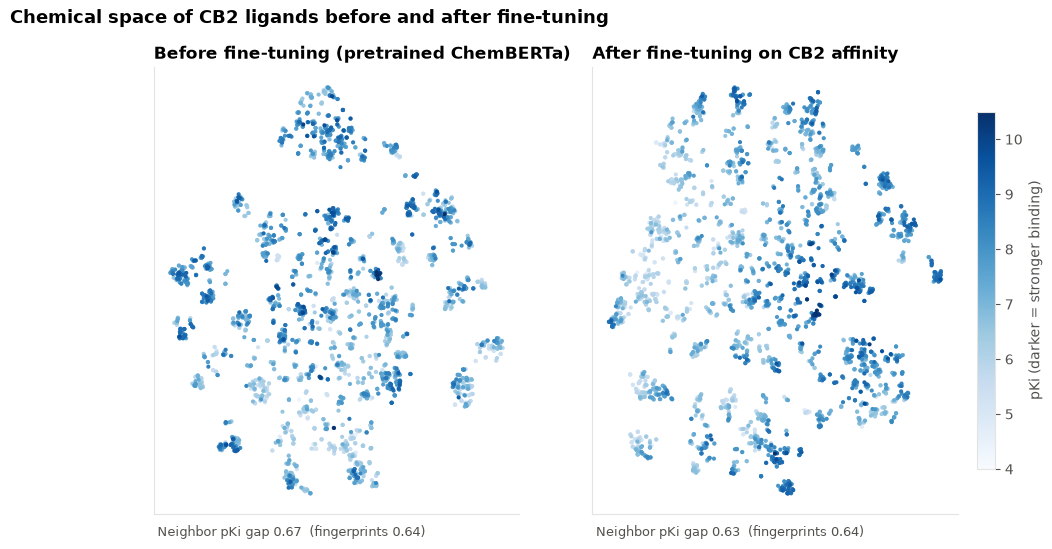

In [10]:
table = molecules["random"]
is_train = (table["subset"] == "train").to_numpy()
is_validation = (table["subset"] == "validation").to_numpy()
pki = table["pki"].to_numpy()

# "Before": the pretrained encoder alone, with the same averaging, never trained on pKi.
encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
chunks = []
with torch.no_grad():
    for batch in batches(table["rdkit_smiles"].to_numpy()):
        piece_vectors, mask = encoder(**batch).last_hidden_state, batch["attention_mask"].unsqueeze(-1).float()
        chunks.append(((piece_vectors * mask).sum(dim=1) / mask.sum(dim=1)).cpu().numpy())
before_vectors = np.vstack(chunks)
del encoder

# Fingerprint bits for the same molecules, in the same order, for the reference number.
row_of = {key: index for index, key in enumerate(smiles_keys)}
bits = fingerprints[[row_of[key] for key in table["rdkit_smiles"]]].astype(float)


def neighbor_gap(similarity):
    # similarity: validation-by-training matrix, higher = more similar. Average |pKi - mean of 10 nearest|.
    nearest = np.argsort(-similarity, axis=1)[:, :10]
    return float(np.mean(np.abs(pki[is_validation] - pki[is_train][nearest].mean(axis=1))))


def cosine_similarity(vectors):
    unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    return unit[is_validation] @ unit[is_train].T


# Tanimoto: shared "on" bits divided by bits on in either molecule; the standard fingerprint similarity.
shared = bits[is_validation] @ bits[is_train].T
tanimoto = shared / (bits[is_validation].sum(1)[:, None] + bits[is_train].sum(1)[None, :] - shared)

gaps = {"No information (training average)": float(np.mean(np.abs(pki[is_validation] - pki[is_train].mean()))),
        "ChemBERTa before fine-tuning": neighbor_gap(cosine_similarity(before_vectors)),
        "Fingerprints (what the SVR uses)": neighbor_gap(tanimoto),
        "ChemBERTa after fine-tuning": neighbor_gap(cosine_similarity(saved_vectors))}
print("Average pKi gap between a validation molecule and its 10 nearest training molecules (lower is better):")
for name, value in gaps.items():
    print(f"  {name:<36} {value:>6.3f} pKi")

# Same t-SNE settings for both maps; the seed makes the layout repeatable.
maps = {title: TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(vectors)
        for title, vectors in [("Before fine-tuning (pretrained ChemBERTa)", before_vectors),
                               ("After fine-tuning on CB2 affinity", saved_vectors)]}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8))
draw_order = np.argsort(pki)   # Strong binders drawn last, so they sit on top.
for ax, (title, xy), gap in zip(axes, maps.items(), [gaps["ChemBERTa before fine-tuning"], gaps["ChemBERTa after fine-tuning"]]):
    points = ax.scatter(xy[draw_order, 0], xy[draw_order, 1], c=pki[draw_order], cmap="Blues", s=9, linewidths=0, vmin=4, vmax=10.5)
    ax.set_title(title, loc="left")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.01, -0.05, f"Neighbor pKi gap {gap:.2f}  (fingerprints {gaps['Fingerprints (what the SVR uses)']:.2f})",
            transform=ax.transAxes, color=INK_SECONDARY, fontsize=9)
colorbar = fig.colorbar(points, ax=axes, shrink=0.8, pad=0.02)
colorbar.set_label("pKi (darker = stronger binding)", color=INK_SECONDARY)
fig.suptitle("Chemical space of CB2 ligands before and after fine-tuning", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.savefig(project_root / "results/chemberta_chemical_space.png", dpi=200, bbox_inches="tight", metadata={"Software": None})
plt.show()

# Both vector sets in TensorBoard's Projector tab, labeled with pKi and subset, to explore in 3D.
writer = SummaryWriter(board_folder / "projector")
labels = [[f"{p:.2f}", s] for p, s in zip(pki, table["subset"])]
writer.add_embedding(torch.from_numpy(before_vectors), metadata=labels, metadata_header=["pKi", "subset"], tag="before_fine_tuning")
writer.add_embedding(torch.from_numpy(saved_vectors), metadata=labels, metadata_header=["pKi", "subset"], tag="after_fine_tuning")
writer.close()

## 8. Save the results

Saved to `provenance/models/fine_tuned_chemberta/`:
- `predictions.csv`: every fold model's predictions for its held-out fold and the validation molecules (no test molecules).
- `epoch_history.csv`: training and held-out error for every epoch of every fold model.
- `frozen_svr_predictions.csv`: the frozen ChemBERTa + SVR model's validation predictions (section 6).
- `configuration.json`: settings, model version, software versions, device, best epochs and the final scores.

The trained weights themselves are not saved (about 14 MB per fold model); rerunning this notebook retrains them. GPU training is not perfectly repeatable, so a rerun's scores can differ slightly in the third decimal.

In [11]:
predictions.to_csv(output_folder / "predictions.csv", index=False)
history.to_csv(output_folder / "epoch_history.csv", index=False)
frozen_predictions.to_csv(output_folder / "frozen_svr_predictions.csv", index=False)
configuration = {
    "model": MODEL_NAME, "parameters": parameter_count, "settings": SETTINGS,
    "device": device_name, "software_versions": {"python": sys.version.split()[0], "torch": torch.__version__,
                                                 "transformers": transformers.__version__, "numpy": np.__version__,
                                                 "pandas": pd.__version__},
    "source_preparation": current_preparation(project_root).as_posix(),
    "source_cv_folds": "provenance/models/support_vector_regression/files/tuning/cv_folds.csv",
    "fold_models": fold_summary.to_dict(orient="records"),
    "validation_scores": results.to_dict(orient="records"),
    "frozen_svr": {"features": "pretrained ChemBERTa molecule vectors (mean of piece vectors), never fine-tuned",
                   "scaling": "StandardScaler fitted on training molecules within each fold",
                   "parameter_grid": FROZEN_GRID, "scoring": svr_configuration["scoring"],
                   "folds": "the tuned SVR's saved cv_folds.csv (PredefinedSplit)", "selection": frozen_selection},
    "noise_floor": NOISE_FLOOR,
}
(output_folder / "configuration.json").write_text(json.dumps(configuration, indent=2) + "\n", encoding="utf-8")

# Read the files back to confirm they hold what was computed, and that no test molecule slipped in.
saved_predictions = pd.read_csv(output_folder / "predictions.csv")
assert len(saved_predictions) == len(predictions)
assert np.allclose(saved_predictions["predicted_pki"], predictions["predicted_pki"])
for split in SPLITS:
    split_test = set(assignments.loc[(assignments["split_strategy"] == split) & (assignments["subset"] == "test"), "rdkit_smiles"])
    assert not split_test & set(saved_predictions.loc[saved_predictions["split_strategy"] == split, "rdkit_smiles"])
assert len(pd.read_csv(output_folder / "epoch_history.csv")) == len(history)
saved_frozen = pd.read_csv(output_folder / "frozen_svr_predictions.csv")
assert np.allclose(saved_frozen["predicted_pki"], frozen_predictions["predicted_pki"])
for split in SPLITS:
    split_test = set(assignments.loc[(assignments["split_strategy"] == split) & (assignments["subset"] == "test"), "rdkit_smiles"])
    assert not split_test & set(saved_frozen.loc[saved_frozen["split_strategy"] == split, "rdkit_smiles"])
print(f"Saved and verified: {len(saved_predictions):,} predictions, {len(history):,} epoch rows, configuration.json")

Saved and verified: 9,733 predictions, 323 epoch rows, configuration.json


## Summary

Generated from the numbers above.

In [12]:
for split in SPLITS:
    svr = results[(results["split_strategy"] == split) & (results["model"] == "Tuned SVR")].iloc[0]
    bert = results[(results["split_strategy"] == split) & (results["model"] == "Fine-tuned ChemBERTa")].iloc[0]
    low, high = np.percentile(differences[split], [2.5, 97.5])
    verdict = "really better" if high < 0 else "really worse" if low > 0 else "not distinguishable from the SVR"
    print(f"{split.upper()}: fine-tuned ChemBERTa RMSE {bert.rmse:.3f} ({bert.gap_closed:.0%} of the gap closed) versus the tuned SVR "
          f"{svr.rmse:.3f} ({svr.gap_closed:.0%}). Difference {differences[split].mean():+.3f} pKi (95% interval {low:+.3f} to {high:+.3f}): "
          f"{verdict}.")
    print()
for split in SPLITS:
    frozen_row = results[(results["split_strategy"] == split) & (results["model"] == "Frozen ChemBERTa + SVR")].iloc[0]
    parts = []
    for other, difference in frozen_differences[split].items():
        low, high = np.percentile(difference, [2.5, 97.5])
        parts.append(f"{difference.mean():+.3f} pKi against {other} (95% interval {low:+.3f} to {high:+.3f}, "
                     f"{'really better' if high < 0 else 'really worse' if low > 0 else 'not distinguishable'})")
    print(f"FROZEN, {split.upper()}: ChemBERTa without fine-tuning, with a tuned SVR on top, RMSE {frozen_row.rmse:.3f} "
          f"({frozen_row.gap_closed:.0%} of the gap closed): " + "; ".join(parts) + ".")
    print()
print(f"SIZE: ChemBERTa has {parameter_count / 1e6:.1f} million trainable parameters and was pretrained on 77 million molecules; "
      f"the SVR works from 2,048 fingerprint bits per molecule.")
print(f"NEIGHBORHOODS: fine-tuning moved ChemBERTa's neighbor pKi gap from {gaps['ChemBERTa before fine-tuning']:.2f} to "
      f"{gaps['ChemBERTa after fine-tuning']:.2f}, against {gaps['Fingerprints (what the SVR uses)']:.2f} for fingerprints and "
      f"{gaps['No information (training average)']:.2f} with no information.")
print()
print("CAVEATS: settings were fixed in advance, not tuned; a tuned transformer could do somewhat better. Validation labels were "
      "inspected during project development, so these are development estimates; the reserved test sets are still unevaluated. "
      "GPU training is not perfectly repeatable, so reruns can differ slightly.")

RANDOM: fine-tuned ChemBERTa RMSE 0.770 (65% of the gap closed) versus the tuned SVR 0.685 (78%). Difference +0.085 pKi (95% interval +0.038 to +0.131): really worse.

SCAFFOLD: fine-tuned ChemBERTa RMSE 0.922 (37% of the gap closed) versus the tuned SVR 0.764 (63%). Difference +0.158 pKi (95% interval +0.108 to +0.206): really worse.

FROZEN, RANDOM: ChemBERTa without fine-tuning, with a tuned SVR on top, RMSE 0.716 (73% of the gap closed): +0.031 pKi against the tuned SVR (95% interval -0.009 to +0.074, not distinguishable); -0.054 pKi against fine-tuned ChemBERTa (95% interval -0.098 to -0.009, really better).

FROZEN, SCAFFOLD: ChemBERTa without fine-tuning, with a tuned SVR on top, RMSE 0.805 (56% of the gap closed): +0.040 pKi against the tuned SVR (95% interval -0.008 to +0.085, not distinguishable); -0.117 pKi against fine-tuned ChemBERTa (95% interval -0.161 to -0.072, really better).

SIZE: ChemBERTa has 3.4 million trainable parameters and was pretrained on 77 million molecu